In [80]:
import numpy as np
import matplotlib.pyplot as plt

#np.random.seed(0)

# Grid
Nx = Ny = 100
dx = dy = 1.0

# PSF
sigma_s = 1.0

# Dynamics
dt = 1.0
sigma_w = 0.5
sigma_u = (np.pi / 360)

# Birth model
PB = 0.01
# birth_means = [
#     np.array([20, 80,  1.0, -0.5,  0.02]),
#     np.array([70, 70, 0, 0, 0]),
#     np.array([80, 20, 0, 0, 0]),
#     np.array([30, 30, 0, 0, 0]),
# ]


x1_0 = np.array([20, 80,  0.9, -0.6,  0.015])  # va vers droite-bas
x2_0 = np.array([80, 80, -0.8, -0.5, 0.015])  # va vers gauche-bas
x3_0 = np.array([80, 20, -0.8,  0.6,  0.012])  # va vers gauche-haut
x4_0 = np.array([20, 20,  0.8,  0.8, -0.012])  # va vers droite-haut

birth_means = [x1_0, x2_0, x3_0, x4_0]


C_birth = np.diag([1,1,1,1,(np.pi/180)**2])

T = 100

In [2]:
def F_matrix(omega):
    if abs(omega) < 1e-6:
        omega = 1e-6
    s = np.sin(omega * dt)
    c = np.cos(omega * dt)
    return np.array([
        [1, 0, s/omega, -(1-c)/omega],
        [0, 1, (1-c)/omega, s/omega],
        [0, 0, c, -s],
        [0, 0, s, c]
    ])

G = np.array([
    [dt**2/2, 0],
    [0, dt**2/2],
    [dt, 0],
    [0, dt]
])

In [50]:
def simulate_truth():
    trajs = [[] for _ in range(4)]

    # fenêtres de vie (papier)
    life = [
        (0, 69),   # t=1:70
        (0, 79),   # t=1:80
        (19, 99),  # t=20:100
        (29, 99)   # t=30:100
    ]

    for i in range(4):
        #x = np.random.multivariate_normal(birth_means[i], C_birth)
        x = birth_means[i].copy()
        for t in range(T):
            start, end = life[i]

            if t < start or t > end:
                trajs[i].append(None)
                continue

            # propagation dynamique
            F = F_matrix(x[4])

            w = sigma_w * np.random.randn(2)
            noise = G @ w

            x[:4] = F @ x[:4] #+ noise
            #x[4] += dt * sigma_u * np.random.randn()

            trajs[i].append(x.copy())

    return trajs

In [4]:
xs = np.arange(Nx)
ys = np.arange(Ny)
Xg, Yg = np.meshgrid(xs, ys, indexing="ij")

def psf(x, I0):
    px, py = x[0], x[1]
    return (dx*dy*I0/(2*np.pi*sigma_s**2)) * \
           np.exp(-((Xg-px)**2 + (Yg-py)**2)/(2*sigma_s**2))

def compute_S(X, I0):
    S = np.zeros((Nx, Ny))
    for x in X:
        S += psf(x, I0)
    return S

def simulate_measurements(trajs, I0):
    Z = []
    for t in range(T):
        X = [traj[t] for traj in trajs if traj[t] is not None]
        S = compute_S(X, I0)
        z = S + np.random.randn(Nx, Ny)  # bruit N(0,1)
        Z.append(z)
    return Z

In [5]:
def plot_trajectories(trajs):
    plt.figure(figsize=(6,6))

    for i, traj in enumerate(trajs):
        pts = np.array([x for x in traj if x is not None])
        plt.plot(pts[:,0], pts[:,1])

        plt.scatter(pts[0,0], pts[0,1], marker='*', s=80)
        plt.scatter(pts[-1,0], pts[-1,1], marker='^', s=80)

    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.title("Ground truth trajectories")
    plt.xlabel("x (m)")
    plt.ylabel("y (m)")
    plt.grid()
    plt.show()

In [6]:
def plot_measurements(Z, times):
    plt.figure(figsize=(4*len(times),4))

    for i, t in enumerate(times):
        plt.subplot(1, len(times), i+1)
        plt.imshow(Z[t], origin='lower')
        plt.title(f"t={t}")
        plt.colorbar()

    plt.tight_layout()
    plt.show()

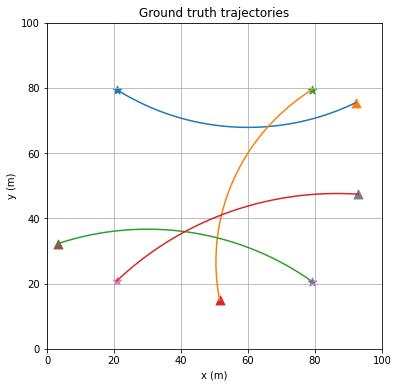

I0 = 15


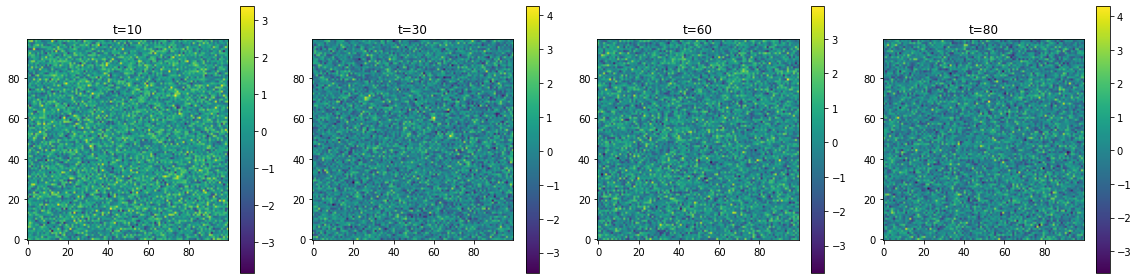

I0 = 20


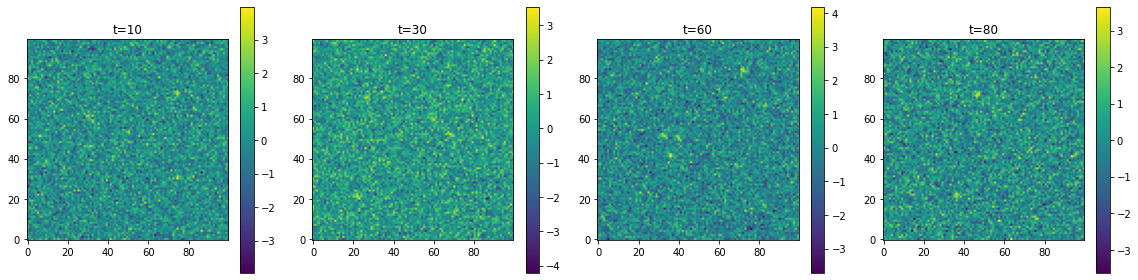

I0 = 25


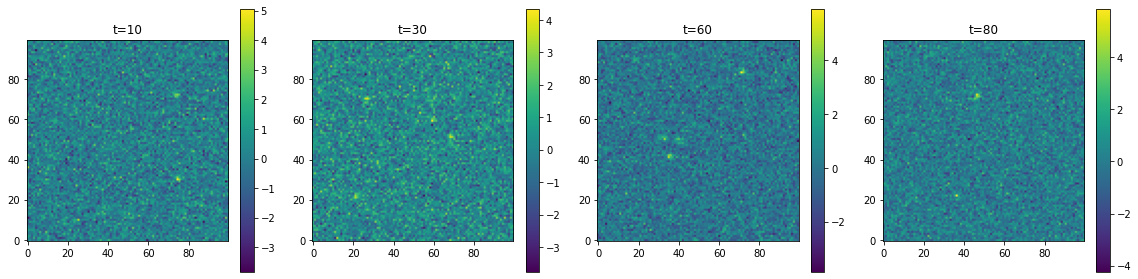

I0 = 30


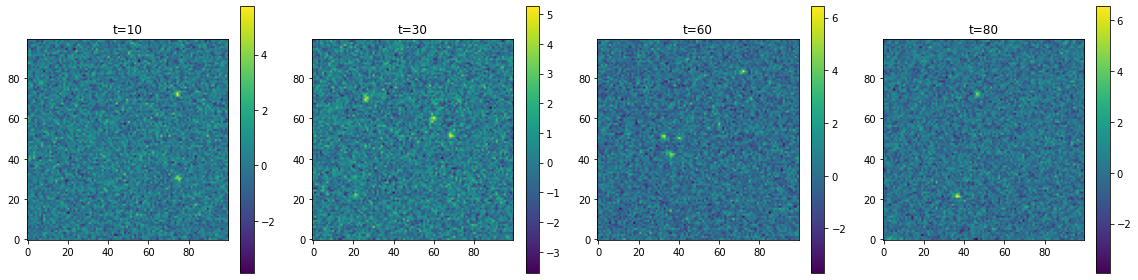

I0 = 35


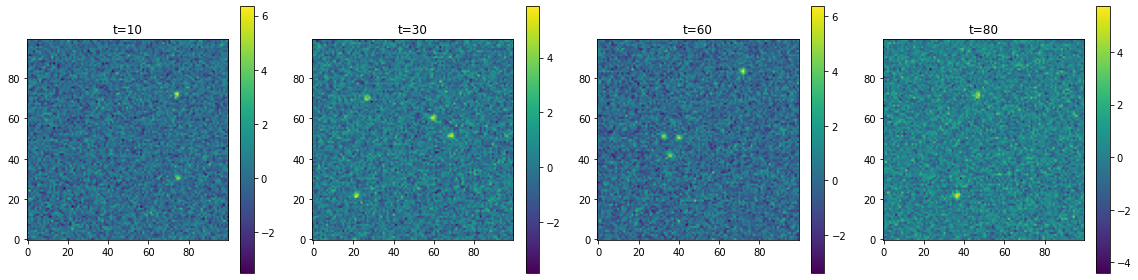

In [81]:
trajs = simulate_truth()

# Figure trajectoires
plot_trajectories(trajs)

# tester plusieurs I0
for I0 in [15, 20, 25, 30, 35]:
    Z = simulate_measurements(trajs, I0)
    print(f"I0 = {I0}")
    plot_measurements(Z, times=[10, 30, 60, 80])

In [46]:
import numpy as np

def estimate_ct_parameters(p0, p1, T):
    p0 = np.array(p0, dtype=float)
    p1 = np.array(p1, dtype=float)

    d = p1 - p0
    dist = np.linalg.norm(d)

    # estimation de courbure (ω)
    # approximation arc de cercle
    omega = 2 * np.sin(dist / (2*T)) / (dist / T + 1e-6)

    # direction moyenne
    v = d / T

    # correction rotationnelle (approx CT)
    R = np.array([[0, -1],
                  [1,  0]])

    v_rot = v + 0.5 * omega * R @ v

    vx, vy = v_rot

    return np.array([vx, vy, omega])

In [48]:
p0 = [20, 80]
pT = [70, 60]
T = 70

vx, vy, w = estimate_ct_parameters(p0, pT, T)

print("vx:", vx)
print("vy:", vy)
print("omega:", w)

vx: 0.8536458084731634
vy: 0.06268594975433706
omega: 0.9755206593121437
